In [22]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt

In [12]:
with open('ISANCA4.csv') as f:
    for i in range(10):
        print(f.readline())

epoch,solarRadiationHigh,winddirAvg,humidityAvg,metric.tempAvg,metric.windspeedAvg,metric.windgustHigh,metric.dewptAvg,metric.pressureMin,metric.precipTotal

1719716694,0.0,295,51.7,3.5,12.4,29.5,-5.5,1006.84,0.0

1719716998,0.0,279,53.0,3.4,8.7,25.6,-5.3,1006.94,0.0

1719717286,0.0,268,54.8,3.3,8.5,21.9,-4.9,1007.01,0.0

1719717590,0.0,292,57.0,3.3,10.4,23.8,-4.4,1007.01,0.0

1719717894,0.0,289,56.8,3.3,13.5,29.5,-4.4,1006.94,0.0

1719718198,0.0,293,57.8,3.3,10.4,21.9,-4.2,1006.94,0.0

1719718486,0.0,283,59.1,3.3,10.9,27.7,-4.0,1006.84,0.0

1719718790,0.0,313,61.4,3.3,10.9,23.8,-3.4,1006.84,0.0

1719719094,0.0,283,60.7,3.4,12.0,25.6,-3.4,1006.74,0.0



In [1]:
import numpy as np
datos_crudos = np.genfromtxt('IBARIL12.csv', dtype=None)

In [2]:
datos_crudos

array(['epoch,solarRadiationHigh,winddirAvg,humidityAvg,metric.tempAvg,metric.windspeedAvg,metric.windgustHigh,metric.dewptAvg,metric.pressureMin,metric.precipTotal',
       '1723547973,0.1,279.0,83.0,2.6,30.6,40.3,0.0,1009.52,0.0',
       '1723548273,0.2,279.0,83.0,2.4,32.4,40.3,-0.2,1009.41,0.0', ...,
       '1788447598,484.7,195,70.3,-3.2,29.8,51.5,-7.8,1016.7,0.0',
       '1788447874,488.9,198,72.0,-3.4,19.9,40.3,-7.7,1016.8,0.0',
       '1788448113,496.4,208,70.1,-3.0,23.1,34.9,-7.7,1016.9,0.0'],
      shape=(210776,), dtype='<U156')

In [3]:
datos_crudos.shape

(210776,)

In [6]:
datos_crudos = np.genfromtxt('IBARIL12.csv', delimiter=',',dtype=None)
datos_crudos

array([['epoch', 'solarRadiationHigh', 'winddirAvg', ...,
        'metric.dewptAvg', 'metric.pressureMin', 'metric.precipTotal'],
       ['1723547973', '0.1', '279.0', ..., '0.0', '1009.52', '0.0'],
       ['1723548273', '0.2', '279.0', ..., '-0.2', '1009.41', '0.0'],
       ...,
       ['1788447598', '484.7', '195', ..., '-7.8', '1016.7', '0.0'],
       ['1788447874', '488.9', '198', ..., '-7.7', '1016.8', '0.0'],
       ['1788448113', '496.4', '208', ..., '-7.7', '1016.9', '0.0']],
      shape=(210776, 10), dtype='<U19')

In [92]:
print(datos_crudos.dtype)

<U19


In [93]:
datos_crudos.shape

(210776, 10)

In [7]:
# primera columna, empezando por la segunda fila
C1 = datos_crudos[1:,0]
epochs = C1.astype('int')

In [8]:
C1

array(['1723547973', '1723548273', '1723548572', ..., '1788447598',
       '1788447874', '1788448113'], shape=(210775,), dtype='<U19')

In [96]:
int(C1[0])

1723547973

In [99]:
columnas = datos_crudos[0,-2]
print(columnas)

metric.pressureMin


In [100]:
temp = datos_crudos[1:,4].astype('float')

In [101]:
pres = datos_crudos[1:,-2].astype('float')

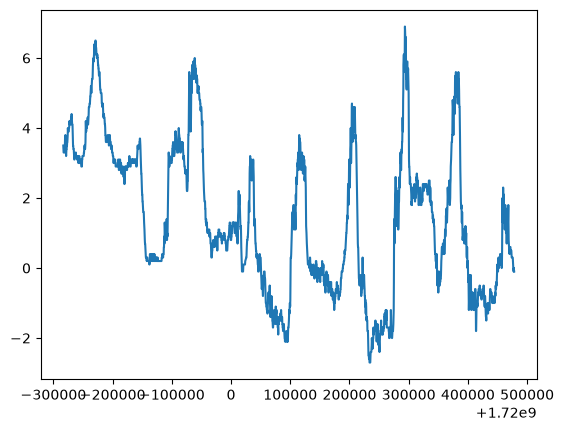

In [52]:
# graficar temperaturas del mes de enero de 2026
import matplotlib.pyplot as plt
plt.plot(epochs, temp)

In [10]:
# tarea: convertir epochs a datetime64

import datetime

In [11]:
datetime.datetime.fromtimestamp(epochs[0])

datetime.datetime(2024, 8, 13, 8, 19, 33)

In [12]:
datetime.datetime.fromtimestamp(epochs)

TypeError: argument must be int or float, not numpy.ndarray

In [13]:
fechas_0 = np.array([datetime.datetime.fromtimestamp(i) for i in epochs ])
fechas_0

array([datetime.datetime(2024, 8, 13, 8, 19, 33),
       datetime.datetime(2024, 8, 13, 8, 24, 33),
       datetime.datetime(2024, 8, 13, 8, 29, 32), ...,
       datetime.datetime(2026, 9, 3, 11, 59, 58),
       datetime.datetime(2026, 9, 3, 12, 4, 34),
       datetime.datetime(2026, 9, 3, 12, 8, 33)],
      shape=(210775,), dtype=object)

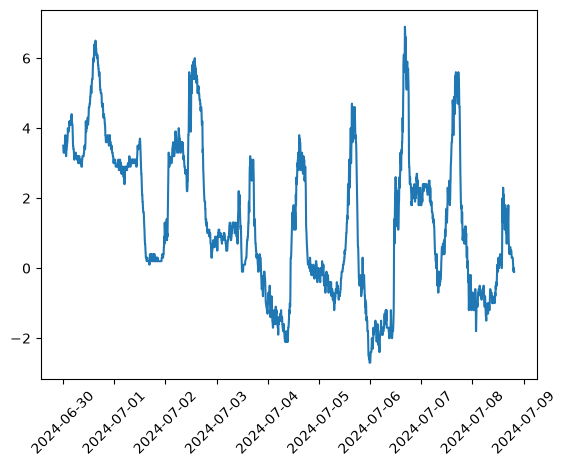

In [64]:
plt.plot(fechas_0, temp)
plt.xticks(rotation=45)
plt.show()

In [14]:
fechas_1 = epochs.astype('datetime64[s]')

In [15]:
fechas_1

array(['2024-08-13T11:19:33', '2024-08-13T11:24:33',
       '2024-08-13T11:29:32', ..., '2026-09-03T14:59:58',
       '2026-09-03T15:04:34', '2026-09-03T15:08:33'],
      shape=(210775,), dtype='datetime64[s]')

In [71]:
df = pd.read_csv('IBARIL12.csv')
df

,epoch,solarRadiationHigh,winddirAvg,humidityAvg,metric.tempAvg,metric.windspeedAvg,metric.windgustHigh,metric.dewptAvg,metric.pressureMin,metric.precipTotal
0,1723547973,0.1,279.0,83.0,2.6,30.6,40.3,0.0,1009.52,0.0
1,1723548273,0.2,279.0,83.0,2.4,32.4,40.3,-0.2,1009.41,0.0
2,1723548572,0.2,279.0,83.0,2.4,32.8,36.7,-0.2,1009.58,0.0
3,1723548873,1.6,276.0,82.7,2.7,29.8,38.5,0.0,1009.31,0.0
4,1723549176,2.8,264.0,82.4,2.6,33.7,64.4,-0.1,1009.58,0.0
...,...,...,...,...,...,...,...,...,...,...
210770,1788446993,465.3,189.0,64.5,-3.0,35.5,53.3,-8.8,1016.59,0.0
210771,1788447282,474.2,197.0,66.6,-3.2,29.4,47.9,-8.6,1016.59,0.0
210772,1788447598,484.7,195.0,70.3,-3.2,29.8,51.5,-7.8,1016.70,0.0
210773,1788447874,488.9,198.0,72.0,-3.4,19.9,40.3,-7.7,1016.80,0.0


In [72]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 210775 entries, 0 to 210774
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   epoch                210775 non-null  int64  
 1   solarRadiationHigh   207218 non-null  float64
 2   winddirAvg           207218 non-null  float64
 3   humidityAvg          207218 non-null  float64
 4   metric.tempAvg       207218 non-null  float64
 5   metric.windspeedAvg  207218 non-null  float64
 6   metric.windgustHigh  207218 non-null  float64
 7   metric.dewptAvg      207217 non-null  float64
 8   metric.pressureMin   210775 non-null  float64
 9   metric.precipTotal   207218 non-null  float64
dtypes: float64(9), int64(1)
memory usage: 16.1 MB


In [90]:
df['fecha'] = pd.to_datetime(df['epoch'], unit='s')
df['fecha']

fecha
2024-08-13 11:19:33   2024-08-13 11:19:33
2024-08-13 11:24:33   2024-08-13 11:24:33
2024-08-13 11:29:32   2024-08-13 11:29:32
2024-08-13 11:34:33   2024-08-13 11:34:33
2024-08-13 11:39:36   2024-08-13 11:39:36
                              ...        
2026-09-03 14:49:53   2026-09-03 14:49:53
2026-09-03 14:54:42   2026-09-03 14:54:42
2026-09-03 14:59:58   2026-09-03 14:59:58
2026-09-03 15:04:34   2026-09-03 15:04:34
2026-09-03 15:08:33   2026-09-03 15:08:33
Name: fecha, Length: 210775, dtype: datetime64[s]

In [82]:
df.set_index('fecha', inplace=True)

<Axes: xlabel='fecha'>

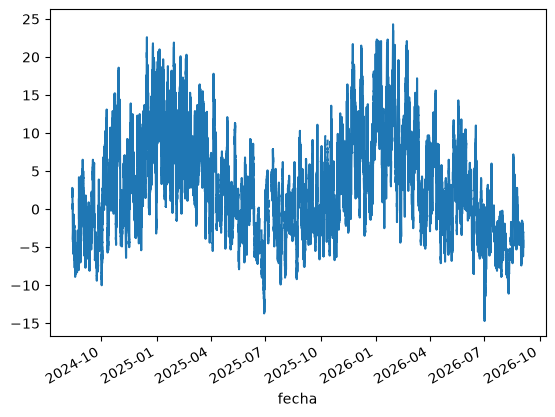

In [84]:
df['metric.tempAvg'].plot()

In [18]:
df2 = pd.read_csv('IDEPAR138.csv')
df2

,epoch,solarRadiationHigh,winddirAvg,humidityAvg,metric.tempAvg,metric.windspeedAvg,metric.windgustHigh,metric.dewptAvg,metric.pressureMin,metric.precipTotal
0,1748055898,0.0,223,22.0,0.4,4.3,14.8,-2.4,855.91,0.0
1,1748056188,0.0,233,22.0,0.4,6.2,14.8,-2.1,855.91,0.0
2,1748056485,0.0,225,22.0,0.3,6.6,18.3,-1.8,855.91,0.0
3,1748056798,0.0,220,21.9,0.3,9.2,20.1,-1.9,856.01,0.0
4,1748057098,0.0,222,22.0,0.1,8.0,18.3,-2.0,856.32,0.0
...,...,...,...,...,...,...,...,...,...,...
122446,1788446685,523.3,274,38.5,-1.6,16.5,29.5,-4.2,858.31,0.0
122447,1788446989,542.5,278,38.1,-1.7,20.4,36.7,-4.3,858.31,0.0
122448,1788447293,501.1,274,37.9,-1.7,26.6,42.2,-4.2,858.11,0.0
122449,1788447581,573.3,282,38.2,-1.7,24.9,38.5,-4.2,858.11,0.0


In [23]:
df2['fecha'] = pd.to_datetime(df2['epoch'], unit='s')
df2.set_index('fecha', inplace=True)


<Axes: xlabel='fecha'>

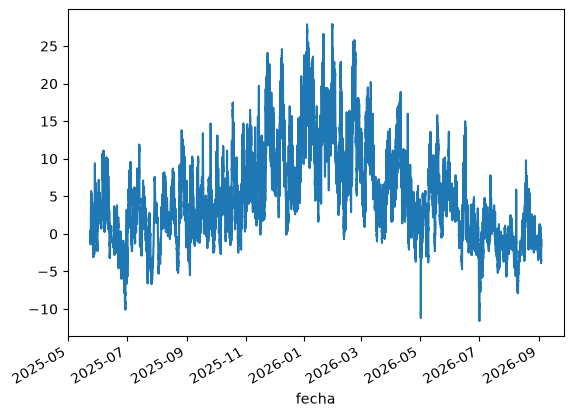

In [24]:
df2['metric.tempAvg'].plot()

In [26]:
df2.index.year

Index([2025, 2025, 2025, 2025, 2025, 2025, 2025, 2025, 2025, 2025,
       ...
       2026, 2026, 2026, 2026, 2026, 2026, 2026, 2026, 2026, 2026],
      dtype='int32', name='fecha', length=122451)

In [28]:
datetime.datetime(2026,9,3).year

2026

In [29]:
len(df2.index.year)

122451

In [31]:
len('palabra')

7

In [33]:
for i in df2.index:
    if i.year==2026:
        if i.month==1:
            print(i)

2026-01-01 00:04:50
2026-01-01 00:09:43
2026-01-01 00:14:46
2026-01-01 00:19:03
2026-01-01 00:24:34
2026-01-01 00:29:59
2026-01-01 00:34:54
2026-01-01 00:39:59
2026-01-01 00:44:57
2026-01-01 00:49:50
2026-01-01 00:54:46
2026-01-01 00:59:35
2026-01-02 00:04:58
2026-01-02 00:09:54
2026-01-02 00:14:54
2026-01-02 00:19:38
2026-01-02 00:24:03
2026-01-02 00:29:40
2026-01-02 00:34:28
2026-01-02 00:39:50
2026-01-02 00:44:59
2026-01-02 00:46:29
2026-01-02 00:54:29
2026-01-02 00:58:03
2026-01-03 00:04:44
2026-01-03 00:09:41
2026-01-03 00:14:26
2026-01-03 00:19:38
2026-01-03 00:24:58
2026-01-03 00:29:53
2026-01-03 00:34:39
2026-01-03 00:39:54
2026-01-03 00:44:43
2026-01-03 00:49:54
2026-01-03 00:54:44
2026-01-03 00:59:38
2026-01-04 00:04:52
2026-01-04 00:09:58
2026-01-04 00:14:39
2026-01-04 00:19:57
2026-01-04 00:24:52
2026-01-04 00:29:57
2026-01-04 00:34:47
2026-01-04 00:39:43
2026-01-04 00:44:43
2026-01-04 00:49:57
2026-01-04 00:54:47
2026-01-04 00:59:46
2026-01-05 00:04:52
2026-01-05 00:09:51


In [35]:
df2['year']=df2.index.year
df2['month']=df2.index.month

In [37]:
df2.loc[df2['year']==2025]  # busqueda por índice

,epoch,solarRadiationHigh,winddirAvg,humidityAvg,metric.tempAvg,metric.windspeedAvg,metric.windgustHigh,metric.dewptAvg,metric.pressureMin,metric.precipTotal,year,month
fecha,,,,,,,,,,,,
2025-05-24 03:04:58,1748055898,0.0,223,22.0,0.4,4.3,14.8,-2.4,855.91,0.0,2025,5
2025-05-24 03:09:48,1748056188,0.0,233,22.0,0.4,6.2,14.8,-2.1,855.91,0.0,2025,5
2025-05-24 03:14:45,1748056485,0.0,225,22.0,0.3,6.6,18.3,-1.8,855.91,0.0,2025,5
2025-05-24 03:19:58,1748056798,0.0,220,21.9,0.3,9.2,20.1,-1.9,856.01,0.0,2025,5
2025-05-24 03:24:58,1748057098,0.0,222,22.0,0.1,8.0,18.3,-2.0,856.32,0.0,2025,5
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31 23:39:34,1767224374,41.0,208,28.0,20.0,11.2,20.1,5.0,860.62,0.0,2025,12
2025-12-31 23:44:54,1767224694,34.6,201,28.0,20.1,7.6,23.8,5.0,860.62,0.0,2025,12
2025-12-31 23:49:54,1767224994,28.7,201,28.0,20.0,9.4,20.1,5.3,860.82,0.0,2025,12


In [38]:
df2['year']==2025

fecha
2025-05-24 03:04:58     True
2025-05-24 03:09:48     True
2025-05-24 03:14:45     True
2025-05-24 03:19:58     True
2025-05-24 03:24:58     True
                       ...  
2026-09-03 14:44:45    False
2026-09-03 14:49:49    False
2026-09-03 14:54:53    False
2026-09-03 14:59:41    False
2026-09-03 15:04:45    False
Name: year, Length: 122451, dtype: bool

In [51]:
indices = (df2['year']==2026) & (df2['month']==1)
df2_enero2026 = df2.loc[ indices ]


<Axes: xlabel='fecha'>

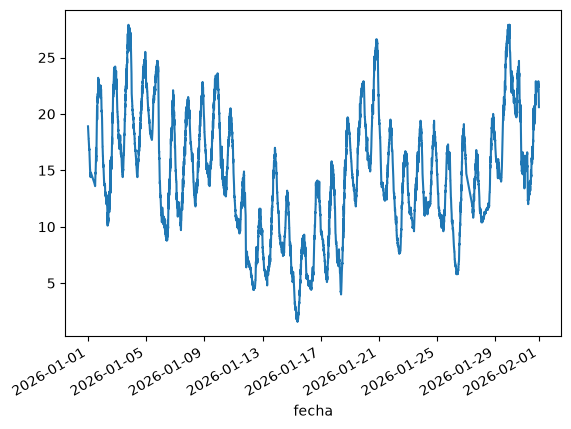

In [52]:
df2_enero2026['metric.tempAvg'].plot()

<Axes: xlabel='fecha'>

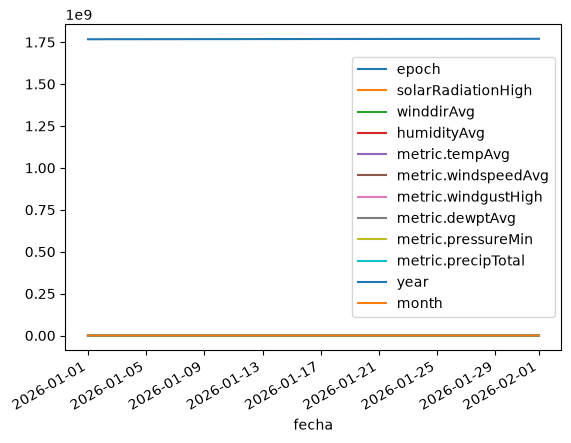

In [54]:
# ejercicio: graficar el mes de enero para cada uno de los sets de datos
#            en el mismo gráfico


In [56]:
df2['year']==2026

fecha
2025-05-24 03:04:58    False
2025-05-24 03:09:48    False
2025-05-24 03:14:45    False
2025-05-24 03:19:58    False
2025-05-24 03:24:58    False
                       ...  
2026-09-03 14:44:45     True
2026-09-03 14:49:49     True
2026-09-03 14:54:53     True
2026-09-03 14:59:41     True
2026-09-03 15:04:45     True
Name: year, Length: 122451, dtype: bool

In [57]:
(df2['year']==2026) & (df2['month']==1)

fecha
2025-05-24 03:04:58    False
2025-05-24 03:09:48    False
2025-05-24 03:14:45    False
2025-05-24 03:19:58    False
2025-05-24 03:24:58    False
                       ...  
2026-09-03 14:44:45    False
2026-09-03 14:49:49    False
2026-09-03 14:54:53    False
2026-09-03 14:59:41    False
2026-09-03 15:04:45    False
Length: 122451, dtype: bool

In [62]:
archivos = ['IBARIL12.csv', 'IBARIL39.csv','IDEPAR123.csv','IDEPAR138.csv']
archivos

['IBARIL12.csv', 'IBARIL39.csv', 'IDEPAR123.csv', 'IDEPAR138.csv']

temp maxima: IBARIL12.csv 24.3
temp maxima: IBARIL12.csv -2.5
temp maxima: IBARIL39.csv 27.1
temp maxima: IBARIL39.csv -0.8
temp maxima: IDEPAR123.csv 23.8
temp maxima: IDEPAR123.csv 14.3
temp maxima: IDEPAR138.csv 27.9
temp maxima: IDEPAR138.csv 1.6


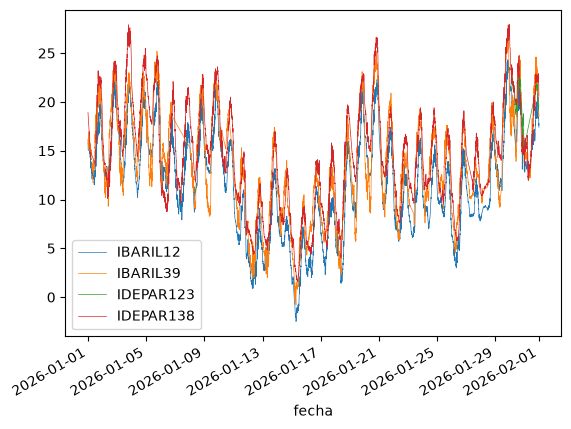

In [78]:
for file in archivos:
    df = pd.read_csv(file)
    df['fecha'] = pd.to_datetime(df['epoch'],unit='s')
    df.set_index('fecha', inplace=True)
    indices = (df.index.year==2026) & (df.index.month==1)
    df_cortado = df.loc[indices]
    print('temp maxima:',file, df_cortado['metric.tempAvg'].max())
    print('temp maxima:',file, df_cortado['metric.tempAvg'].min())


    
    df_cortado['metric.tempAvg'].plot(linewidth = 0.5, label=file.split('.')[0])
    plt.legend()

In [68]:
indices

array([False, False, False, ..., False, False, False], shape=(122451,))